#### Comparison across Census Adress Count Listing housing counts and location counts from FCC

**Key Finding(s)**:
1. Large gap exists between AddressCounts and FCC Location Units
2. Claude hypothesis (needs to be validated):
    * Census housing unit = an individual dwelling unit. An apartment building with 100 apartments = 100 housing units.
    * FCC location_id = a Broadband Serviceable Location (BSL), which is essentially a unique address/structure. That same apartment building = 1 location. So FCC will always be lower than Census in areas with multi-family housing. This isn't a bug — it's a definitional difference. Dense urban counties (NYC, LA, Chicago) will show the largest gaps because they have the most multi-unit buildings.
3. CostQuest visual on the topic: https://www.costquest.com/broadband-serviceable-location-fabric/fabric-unit-counts-vs-us-census-2022-unit-counts-dashboard/

In [1]:
# ── Cell 1: Imports & paths
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SPEEDS_DIR = Path("/home/eprashar_solutions_corelogic_com/network-idx/data/processed/fcc/speeds")
ACL_DIR = Path("/home/eprashar_solutions_corelogic_com/network-idx/data/processed/census/addcountlisting2025")

LOC_COLS = ["cable_location_count", "copper_location_count", "fiber_location_count"]

In [2]:
# ── Cell 2: Load all states — block-level merge

speed_files = sorted(SPEEDS_DIR.glob("fcc_fixed_speeds_??_??.parquet"))
acl_files = sorted(ACL_DIR.glob("census_acl_??_??.parquet"))

print(f"Speed parquets: {len(speed_files)}, ACL parquets: {len(acl_files)}")

# Load speeds — only need block_geoid + location counts + state identifiers
speed_dfs = []
for f in speed_files:
    df = pd.read_parquet(f, columns=["block_geoid", "state_usps", "state_fips"] + LOC_COLS)
    speed_dfs.append(df)
speeds = pd.concat(speed_dfs, ignore_index=True)

# Max location count across the three technologies
speeds["fcc_max_location_count"] = speeds[LOC_COLS].max(axis=1)

# Load ACL — only need block_geoid + counts
acl_dfs = []
for f in acl_files:
    df = pd.read_parquet(f, columns=["block_geoid", "state_usps", "county_geoid",
                                      "total_housing_units", "total_group_quarters"])
    acl_dfs.append(df)
acl = pd.concat(acl_dfs, ignore_index=True)

print(f"FCC blocks: {len(speeds):,}  |  Census blocks: {len(acl):,}")

Speed parquets: 56, ACL parquets: 56
FCC blocks: 5,941,992  |  Census blocks: 8,284,328


In [3]:
# ── Cell 3: Merge on block_geoid (outer join to see coverage gaps)

merged = acl.merge(
    speeds[["block_geoid", "fcc_max_location_count"]],
    on="block_geoid",
    how="left",
)
# Blocks with no FCC data → 0 locations
merged["fcc_max_location_count"] = merged["fcc_max_location_count"].fillna(0).astype(int)

print(f"Merged blocks: {len(merged):,}")
print(f"Blocks with FCC data: {(merged['fcc_max_location_count'] > 0).sum():,}")
print(f"Blocks with 0 FCC locations: {(merged['fcc_max_location_count'] == 0).sum():,}")
merged.head(10)

Merged blocks: 8,284,328
Blocks with FCC data: 5,890,098
Blocks with 0 FCC locations: 2,394,230


,block_geoid,state_usps,county_geoid,total_housing_units,total_group_quarters,fcc_max_location_count
0,020130001001000,AK,02013,0,0,0
1,020130001001001,AK,02013,0,0,0
2,020130001001002,AK,02013,0,0,0
3,020130001001003,AK,02013,0,0,0
4,020130001001004,AK,02013,0,0,0
5,020130001001005,AK,02013,0,0,0
6,020130001001006,AK,02013,0,0,0
7,020130001001007,AK,02013,0,0,0
8,020130001001008,AK,02013,0,0,0
9,020130001001009,AK,02013,0,0,0


In [8]:
# ── Cell 4: State-level summary

state_summary = merged.groupby(["state_usps"], as_index=False).agg(
    census_housing_units=("total_housing_units", "sum"),
    #census_group_quarters=("total_group_quarters", "sum"),
    fcc_max_locations=("fcc_max_location_count", "sum"),
    block_count=("block_geoid", "count"),
)
state_summary["census_total"] = state_summary["census_housing_units"] # + state_summary["census_group_quarters"]
state_summary["abs_diff"] = (state_summary["fcc_max_locations"] - state_summary["census_housing_units"]).abs()
state_summary["pct_diff"] = (state_summary["abs_diff"] / state_summary["census_housing_units"] * 100).round(1)
state_summary = state_summary.sort_values("state_usps")

# print(state_summary.to_string(index=False))
# Format integers with commas and display as a styled table
display(
    state_summary.style
    .format({
        "census_housing_units": "{:,.0f}",
        #"census_group_quarters": "{:,.0f}",
        "fcc_max_locations": "{:,.0f}",
        "block_count": "{:,.0f}",
        "census_total": "{:,.0f}",
        "abs_diff": "{:,.0f}",
        "pct_diff": "{:.1f}%",
    })
    .set_table_styles([
        {"selector": "th, td", "props": [("border", "1px solid #ccc"), ("padding", "6px 10px")]},
        {"selector": "table", "props": [("border-collapse", "collapse")]},
    ])
    .hide(axis="index")
)

state_usps,census_housing_units,fcc_max_locations,block_count,census_total,abs_diff,pct_diff
AK,"672,870","223,136","28,690","672,870","449,734",66.8%
AL,"4,921,874","1,969,228","189,713","4,921,874","2,952,646",60.0%
AR,"2,941,232","1,222,777","139,333","2,941,232","1,718,455",58.4%
AS,"23,350","8,842",566,"23,350","14,508",62.1%
AZ,"6,757,750","2,508,169","159,134","6,757,750","4,249,581",62.9%
CA,"29,995,724","9,721,833","522,112","29,995,724","20,273,891",67.6%
CO,"5,425,132","1,850,456","142,554","5,425,132","3,574,676",65.9%
CT,"3,150,404","1,080,770","49,948","3,150,404","2,069,634",65.7%
DC,"782,742","123,323","6,013","782,742","659,419",84.2%
DE,"978,818","389,015","20,450","978,818","589,803",60.3%


In [4]:
# ── True nunique location_id per block (from raw extracted CSVs)
# This will be slower — reads all raw CSVs

from network_idx.constants import FIXED_TECHNOLOGIES_MAPPING

EXTRACTED_DIR = Path("/home/eprashar_solutions_corelogic_com/network-idx/data/extracted/fcc/speeds")

nunique_dfs = []
for state_dir in sorted(EXTRACTED_DIR.iterdir()):
    if not state_dir.is_dir():
        continue
    for csv_path in state_dir.glob("*.csv"):
        df = pd.read_csv(
            csv_path,
            usecols=["block_geoid", "location_id", "technology"],
            dtype={"block_geoid": str, "location_id": str, "technology": int},
        )
        # Filter to fixed techs only
        df = df[df["technology"].isin(FIXED_TECHNOLOGIES_MAPPING.values())]
        nunique_dfs.append(df[["block_geoid", "location_id"]])

all_locs = pd.concat(nunique_dfs, ignore_index=True)
true_nunique = (
    all_locs.groupby("block_geoid")["location_id"]
    .nunique()
    .rename("fcc_true_nunique")
    .reset_index()
)

print(f"Blocks with FCC data: {len(true_nunique):,}")
print(f"Total unique locations: {true_nunique['fcc_true_nunique'].sum():,}")

Blocks with FCC data: 5,941,992
Total unique locations: 110,632,782


In [5]:
# Add true nunique to the merged dataframe
compare = merged.merge(true_nunique, on="block_geoid", how="left")
compare["fcc_true_nunique"] = compare["fcc_true_nunique"].fillna(0).astype(int)

state_compare = compare.groupby("state_usps", as_index=False).agg(
    census_hu=("total_housing_units", "sum"),
    fcc_max_tech=("fcc_max_location_count", "sum"),
    fcc_nunique=("fcc_true_nunique", "sum"),
)
state_compare["max_vs_nunique_diff"] = state_compare["fcc_nunique"] - state_compare["fcc_max_tech"]
state_compare["hu_vs_nunique_ratio"] = (state_compare["census_hu"] / state_compare["fcc_nunique"]).round(2)

display(
    state_compare.style
    .format("{:,.0f}", subset=["census_hu", "fcc_max_tech", "fcc_nunique", "max_vs_nunique_diff"])
    .format("{:.2f}", subset=["hu_vs_nunique_ratio"])
    .set_table_styles([
        {"selector": "th, td", "props": [("border", "1px solid #ccc"), ("padding", "6px 10px")]},
        {"selector": "table", "props": [("border-collapse", "collapse")]},
    ])
    .hide(axis="index")
)

state_usps,census_hu,fcc_max_tech,fcc_nunique,max_vs_nunique_diff,hu_vs_nunique_ratio
AK,"672,870","223,136","226,787","3,651",2.97
AL,"4,921,874","1,969,228","1,994,130","24,902",2.47
AR,"2,941,232","1,222,777","1,237,165","14,388",2.38
AS,"23,350","8,842","8,842",0,2.64
AZ,"6,757,750","2,508,169","2,537,786","29,617",2.66
CA,"29,995,724","9,721,833","9,778,194","56,361",3.07
CO,"5,425,132","1,850,456","1,859,477","9,021",2.92
CT,"3,150,404","1,080,770","1,085,245","4,475",2.90
DC,"782,742","123,323","123,384",61,6.34
DE,"978,818","389,015","390,628","1,613",2.51


In [6]:
# ── Cell 5: State-county-level summary

county_summary = merged.groupby(["state_usps", "county_geoid"], as_index=False).agg(
    census_housing_units=("total_housing_units", "sum"),
    census_group_quarters=("total_group_quarters", "sum"),
    fcc_max_locations=("fcc_max_location_count", "sum"),
    block_count=("block_geoid", "count"),
)
county_summary["abs_diff"] = (county_summary["fcc_max_locations"] - county_summary["census_housing_units"]).abs()
county_summary["pct_diff"] = (
    county_summary["abs_diff"] / county_summary["census_housing_units"].replace(0, float("nan")) * 100
).round(1)
county_summary = county_summary.sort_values("county_geoid")

print(f"Counties: {len(county_summary):,}")
county_summary.head(20)

Counties: 3,292


,state_usps,county_geoid,census_housing_units,census_group_quarters,fcc_max_locations,block_count,abs_diff,pct_diff
31,AL,01001,26104,24,23098,1541,3006,11.5
32,AL,01003,144000,73,93031,6762,50969,35.4
33,AL,01005,12224,22,11423,1283,801,6.6
34,AL,01007,9598,13,5188,1092,4410,45.9
35,AL,01009,26255,27,21883,2435,4372,16.7
36,AL,01011,4806,20,4841,573,35,0.7
37,AL,01013,10123,8,8377,1238,1746,17.2
38,AL,01015,54836,119,49910,4879,4926,9.0
39,AL,01017,17218,11,15932,1719,1286,7.5
40,AL,01019,15747,5,15430,1566,317,2.0


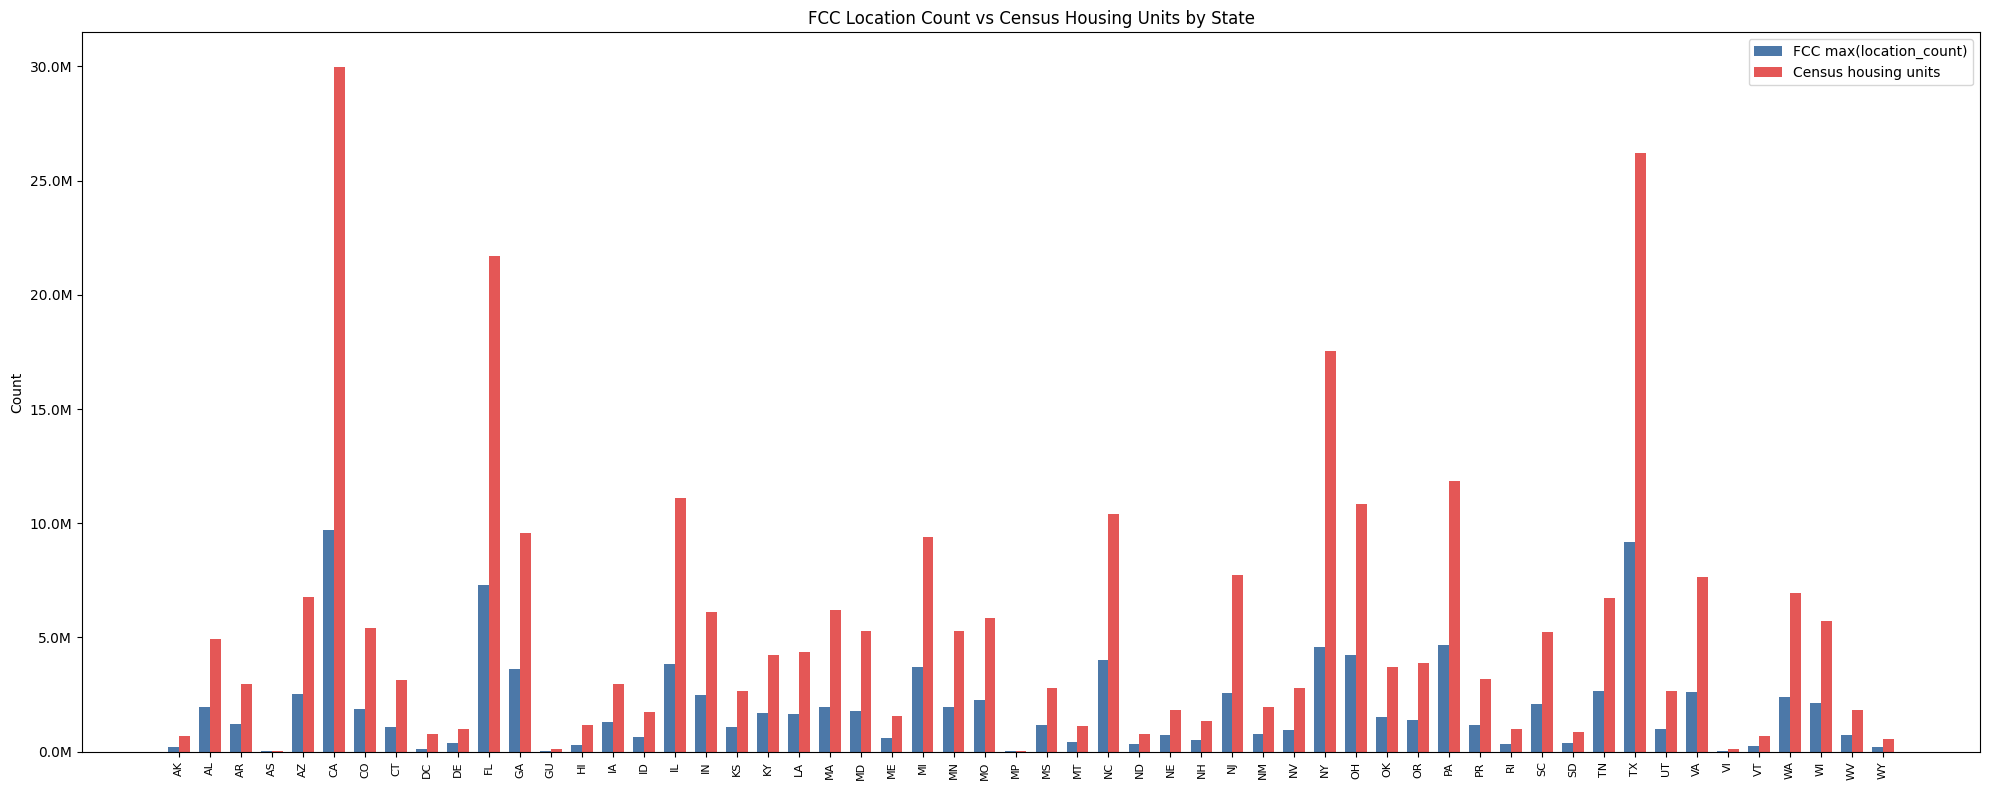

In [9]:
# ── Cell 6: Bar chart — State-level FCC vs Census

fig, ax = plt.subplots(figsize=(20, 8))
x = range(len(state_summary))
width = 0.35

ax.bar([i - width/2 for i in x], state_summary["fcc_max_locations"],
       width, label="FCC max(location_count)", color="#4C78A8")
ax.bar([i + width/2 for i in x], state_summary["census_housing_units"],
       width, label="Census housing units", color="#E45756")

ax.set_xticks(list(x))
ax.set_xticklabels(state_summary["state_usps"], rotation=90, fontsize=8)
ax.set_ylabel("Count")
ax.set_title("FCC Location Count vs Census Housing Units by State")
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
plt.tight_layout()
plt.show()

Counties matching criteria: 50


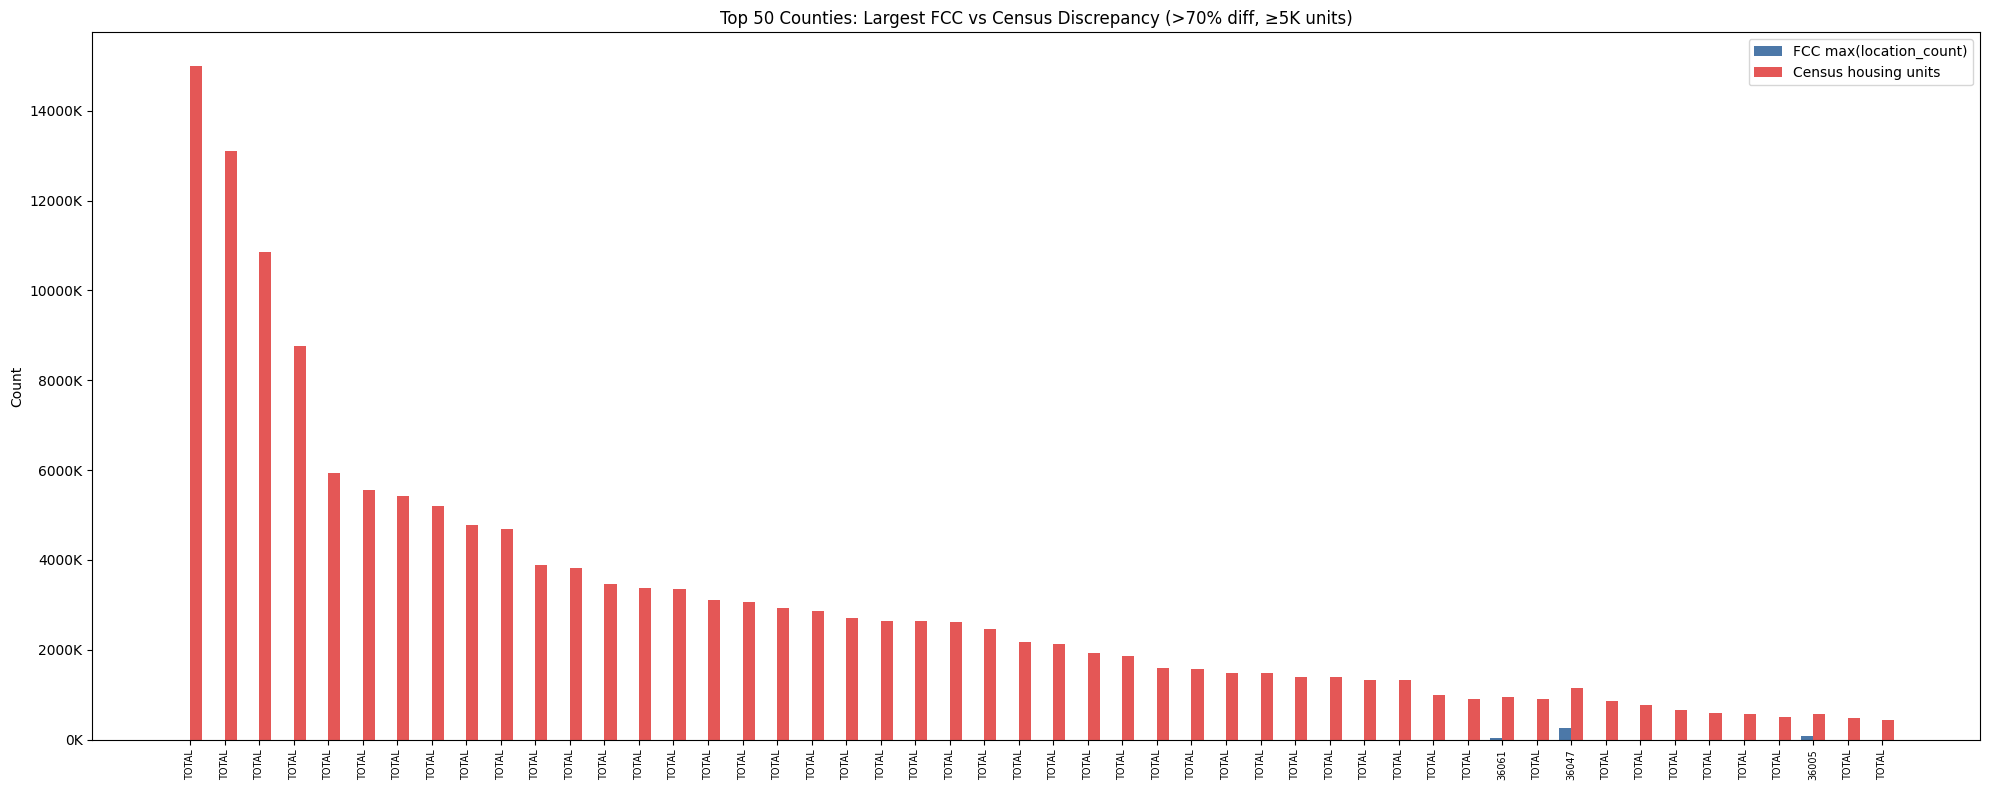

In [10]:
# ── Cell 7: Top 50 counties with widest discrepancy
# Filter: abs diff > 70% AND census housing units >= 5000

big_gaps = county_summary[
    (county_summary["pct_diff"] > 70) &
    (county_summary["census_housing_units"] >= 5000)
].nlargest(50, "abs_diff")

print(f"Counties matching criteria: {len(big_gaps)}")

fig, ax = plt.subplots(figsize=(20, 8))
x = range(len(big_gaps))
width = 0.35

ax.bar([i - width/2 for i in x], big_gaps["fcc_max_locations"],
       width, label="FCC max(location_count)", color="#4C78A8")
ax.bar([i + width/2 for i in x], big_gaps["census_housing_units"],
       width, label="Census housing units", color="#E45756")

ax.set_xticks(list(x))
ax.set_xticklabels(big_gaps["county_geoid"], rotation=90, fontsize=7)
ax.set_ylabel("Count")
ax.set_title("Top 50 Counties: Largest FCC vs Census Discrepancy (>70% diff, ≥5K units)")
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}K"))
plt.tight_layout()
plt.show()